# 24 - Expression Quality Control and Variability Assessment

### Objective

This notebook performs quality-control and variability assessment of the harmonized DepMap expression layer generated in Notebook 23.

The goal is to characterize the structure, distribution, and variability of the transcriptomic matrix before using it in downstream dimensionality reduction, lineage-aware exploratory analyses, and pharmacogenomic integration workflows.

### Scope of this notebook

This notebook is limited to transcriptomic quality assessment and feature-space characterization of the harmonized expression layer. It does not perform predictive modeling, resistance-like phenotype construction, drug-response integration, candidate program discovery, or biological interpretation.

### Input files

- `data/interim/23_expression_harmonized.parquet`

### Expected outputs

- `data/interim/24_expression_qc_summary.csv`
- `data/interim/24_gene_variability_summary.csv`
- Candidate variance-based filtering thresholds for downstream preprocessing

### Key questions

1. What are the global distributional and variability characteristics of the harmonized transcriptomic layer?
2. How are expression values distributed across genes and cell lines?
3. Which genes show zero, near-zero, low, moderate, or high variability?
4. How many genes would be retained under conservative variance-based filtering thresholds?
5. Are expression profiles broadly comparable across cell lines before downstream analyses?
6. Do any cell lines exhibit atypical global expression profiles that may warrant additional quality-control review?

### Methodological notes

Any feature filtering performed in this notebook should be treated as preprocessing rather than biological discovery. Variance-based filtering is used exclusively to identify uninformative or weakly informative features and should not be interpreted as evidence of biological relevance.

This notebook focuses exclusively on transcriptomic quality assessment and feature-space characterization. Any variability-based filtering thresholds generated in this stage should be interpreted as preprocessing recommendations and will require downstream evaluation before implementation.

Lineage-aware analyses, dimensionality reduction, candidate program discovery, and biological interpretation are deferred to subsequent notebooks.

In [1]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.paths import Paths

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [2]:
# =============================================================================
# Paths
# =============================================================================

PROJECT_ROOT = Paths.root

INTERIM_DIR = Paths.interim

EXPRESSION_PATH = (
    INTERIM_DIR / "23_expression_harmonized.parquet"
)

COHORT_PATH = (
    INTERIM_DIR / "22_integrated_modeling_cohort.csv"
)



In [3]:
# =============================================================================
# Load cohort and harmonized expression matrix
# =============================================================================
cohort = pd.read_csv(COHORT_PATH)

expression = pd.read_parquet(EXPRESSION_PATH)

print(f"Expression shape: {expression.shape}")

Expression shape: (713, 19194)


In [4]:
# =============================================================================
# Initial inspection
# =============================================================================

display(expression.head())

print("\nColumn types:")
display(
    expression.dtypes
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="count")
)

print(f"\nTotal columns: {expression.shape[1]:,}")
print(f"Total models : {expression.shape[0]:,}")
print(f"Total genes  : {expression.shape[1] - 1:,}")

,ModelID,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,H3C2 (8358),H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038)
0,ACH-000242,6.729417,0.000000,6.537917,2.456806,3.867897,0.799087,7.208478,5.570159,7.127117,...,1.117695,2.358959,0.084064,1.910733,0.000000,0.000000,0.464668,0.000000,0.000000,0.000000
1,ACH-000708,4.272770,0.189034,7.023255,2.555816,3.841973,0.000000,0.097611,4.888500,4.926948,...,1.367371,1.480265,0.321928,1.891419,0.201634,0.000000,0.000000,0.000000,0.000000,0.000000
2,ACH-000233,0.056584,0.000000,6.094236,3.971773,3.731183,0.028569,6.093603,3.033864,3.422233,...,0.879706,1.244887,0.641546,3.157044,0.226509,0.000000,0.000000,0.056584,0.000000,0.000000
3,ACH-000528,4.512227,0.000000,7.099926,2.843984,4.672991,0.014355,0.815575,6.709153,3.982765,...,1.292782,0.584962,0.321928,2.592158,0.000000,0.028569,0.042644,0.000000,0.028569,0.000000
4,ACH-001655,3.592158,0.000000,6.747387,0.925999,1.839960,0.028569,0.056584,5.350851,1.815575,...,1.389567,1.063503,0.014355,1.298658,0.321928,0.014355,0.000000,0.000000,0.014355,0.594549



Column types:


,dtype,count
0,float32,19193
1,object,1



Total columns: 19,194
Total models : 713
Total genes  : 19,193


#### **Harmonized Expression Matrix Overview**

The harmonized transcriptomic matrix generated in Notebook 23 was loaded from its persisted Parquet representation.

The matrix contains 713 cell lines and 19,193 transcriptomic features, plus the corresponding `ModelID` identifier column. Transcriptomic features are stored as `float32`, reducing memory requirements while maintaining sufficient numerical precision for downstream transcriptomic analyses.

This notebook evaluates the distributional properties and variability structure of this matrix before any dimensionality reduction or downstream integration analyses.

---

## Sample-Level Distribution Analysis

The first quality-control assessment focuses on transcriptomic distributions at the cell-line level.

The objective is to identify potential outlier models exhibiting unusual global expression profiles that may reflect technical artifacts, preprocessing inconsistencies, or biologically extreme transcriptomic states.

At this stage, no samples will be removed. The analysis is purely descriptive and intended to establish baseline distributional characteristics across the integrated cohort.

In [5]:
# =============================================================================
# Sample-level expression summary
# =============================================================================

expression_only = expression.drop(columns="ModelID")

sample_summary = pd.DataFrame({
    "ModelID": expression["ModelID"],
    "mean_expression": expression_only.mean(axis=1),
    "median_expression": expression_only.median(axis=1),
    "std_expression": expression_only.std(axis=1),
    "min_expression": expression_only.min(axis=1),
    "max_expression": expression_only.max(axis=1)
})

display(sample_summary.head())

,ModelID,mean_expression,median_expression,std_expression,min_expression,max_expression
0,ACH-000242,2.656216,2.469886,2.537690,0.0,15.636229
1,ACH-000708,2.586653,2.313246,2.526030,0.0,15.731796
2,ACH-000233,2.619533,2.397803,2.547848,0.0,15.114922
3,ACH-000528,2.643791,2.350497,2.592020,0.0,15.528759
4,ACH-001655,2.274788,1.757023,2.400705,0.0,14.777974


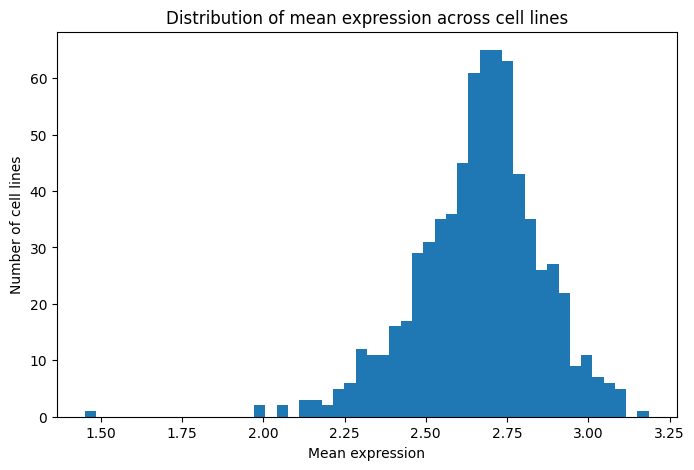

In [6]:
# =============================================================================
# Mean expression per sample
# =============================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    sample_summary["mean_expression"],
    bins=50
)

plt.xlabel("Mean expression")
plt.ylabel("Number of cell lines")
plt.title("Distribution of mean expression across cell lines")

plt.show()

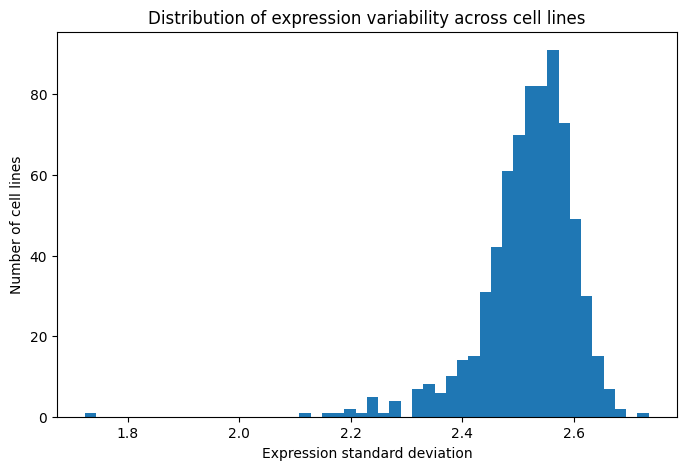

In [7]:
# =============================================================================
# Expression variability per sample
# =============================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    sample_summary["std_expression"],
    bins=50
)

plt.xlabel("Expression standard deviation")
plt.ylabel("Number of cell lines")
plt.title("Distribution of expression variability across cell lines")

plt.show()

In [8]:
# =============================================================================
# Potential sample outliers
# =============================================================================

mean_zscore = (
    sample_summary["mean_expression"]
    - sample_summary["mean_expression"].mean()
) / sample_summary["mean_expression"].std()

std_zscore = (
    sample_summary["std_expression"]
    - sample_summary["std_expression"].mean()
) / sample_summary["std_expression"].std()

sample_summary["mean_zscore"] = mean_zscore
sample_summary["std_zscore"] = std_zscore

potential_outliers = sample_summary[
    (mean_zscore.abs() > 3)
    | (std_zscore.abs() > 3)
]

print(f"Potential outliers: {len(potential_outliers)}")

display(
    potential_outliers.sort_values(
        "std_zscore",
        key=np.abs,
        ascending=False
    )
)

Potential outliers: 13


,ModelID,mean_expression,median_expression,std_expression,min_expression,max_expression,mean_zscore,std_zscore
109,ACH-001400,1.451985,0.910733,1.723643,0.0,17.022379,-6.306655,-9.206183
425,ACH-000979,1.972331,1.427606,2.113997,0.0,16.938145,-3.598354,-4.683098
477,ACH-001642,1.994200,1.438293,2.154831,0.0,15.963641,-3.484533,-4.209958
82,ACH-000544,2.066603,1.521051,2.176702,0.0,17.031239,-3.107689,-3.956532
650,ACH-000794,2.133146,1.713696,2.189342,0.0,16.932388,-2.761344,-3.810077
519,ACH-000624,2.430581,2.277985,2.207673,0.0,16.891914,-1.213254,-3.597673
253,ACH-000188,2.222745,1.815575,2.220938,0.0,17.249992,-2.294998,-3.443960
303,ACH-000472,2.247687,1.903038,2.235395,0.0,16.323759,-2.165183,-3.276445
81,ACH-000858,2.246328,1.871844,2.236753,0.0,17.059080,-2.172254,-3.260720
451,ACH-000873,2.513106,2.356144,2.238532,0.0,17.059080,-0.783725,-3.240103


In [9]:
# =============================================================================
# Outlier lineage inspection
# =============================================================================

outlier_metadata = (
    potential_outliers[["ModelID"]]
    .merge(
        cohort,
        on="ModelID",
        how="left"
    )
)

display(
    outlier_metadata[
        [
            "ModelID",
            "CellLineName",
            "OncotreeLineage",
            "OncotreePrimaryDisease"
        ]
    ]
)

,ModelID,CellLineName,OncotreeLineage,OncotreePrimaryDisease
0,ACH-001336,Ca Ski,Cervix,Cervical Squamous Cell Carcinoma
1,ACH-000858,KNS-62,Lung,Non-Small Cell Lung Cancer
2,ACH-000544,OE21,Esophagus/Stomach,Esophageal Squamous Cell Carcinoma
3,ACH-001400,SW 954,Vulva/Vagina,Squamous Cell Carcinoma of the Vulva/Vagina
4,ACH-000002,HL-60,Myeloid,Acute Myeloid Leukemia
5,ACH-000188,SCC-25,Head and Neck,Head and Neck Squamous Cell Carcinoma
6,ACH-000472,HSC-2,Head and Neck,Head and Neck Squamous Cell Carcinoma
7,ACH-000979,DU 145,Prostate,Prostate Adenocarcinoma
8,ACH-000873,KYSE-270,Esophagus/Stomach,Esophageal Squamous Cell Carcinoma
9,ACH-001642,SCC-3,Lymphoid,Non-Hodgkin Lymphoma


### Sample-Level Distribution Assessment

A total of 13 cell lines were identified as potential outliers based on global expression mean and standard-deviation z-scores.

Inspection of the corresponding metadata did not reveal evidence of obvious technical artifacts. Instead, these models originate from biologically diverse lineages, including myeloid, lymphoid, prostate, breast, colorectal, lung, and multiple squamous-cell carcinoma contexts.

The observed deviations therefore likely reflect underlying biological heterogeneity rather than data-quality issues.

Consequently, no samples were excluded from the integrated cohort at this stage. Potential outliers will be retained for subsequent lineage-aware analyses.

---

## Gene-Level Variability Assessment

This section evaluates variability across transcriptomic features.

The goal is to identify genes with absent, near-zero, low, moderate, or high variability across the integrated cohort. These metrics are used only to characterize the feature space and to inform potential downstream preprocessing decisions.

No genes are removed in this section.

In [24]:
# =============================================================================
# Gene-level variability summary
# =============================================================================

gene_summary = pd.DataFrame({
    "gene": expression_only.columns,
    "mean_expression": expression_only.mean(axis=0),
    "median_expression": expression_only.median(axis=0),
    "std_expression": expression_only.std(axis=0),
    "variance": expression_only.var(axis=0),
    "min_expression": expression_only.min(axis=0),
    "max_expression": expression_only.max(axis=0),
})

display(gene_summary.head())

,gene,mean_expression,median_expression,std_expression,variance,min_expression,max_expression
TSPAN6 (7105),TSPAN6 (7105),3.263957,3.726831,1.667567,2.780779,0.000000,8.132680
TNMD (64102),TNMD (64102),0.044743,0.000000,0.225873,0.051019,0.000000,3.401903
DPM1 (8813),DPM1 (8813),6.511205,6.489286,0.604845,0.365837,3.894333,9.175250
SCYL3 (57147),SCYL3 (57147),2.433656,2.400538,0.576802,0.332700,0.855990,4.747387
C1orf112 (55732),C1orf112 (55732),3.810973,3.837943,0.708045,0.501328,1.063503,5.972463


In [25]:
# =============================================================================
# Variance quantiles
# =============================================================================

variance_quantiles = gene_summary["variance"].quantile(
    [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]
)

display(
    variance_quantiles
    .rename("variance")
    .reset_index()
    .rename(columns={"index": "quantile"})
)

,quantile,variance
0,0.00,0.000000
1,0.01,0.000125
2,0.05,0.009420
3,0.10,0.061709
4,0.25,0.340686
5,0.50,0.578146
6,0.75,1.283302
7,0.90,2.614816
8,0.95,3.766832
9,0.99,6.893603


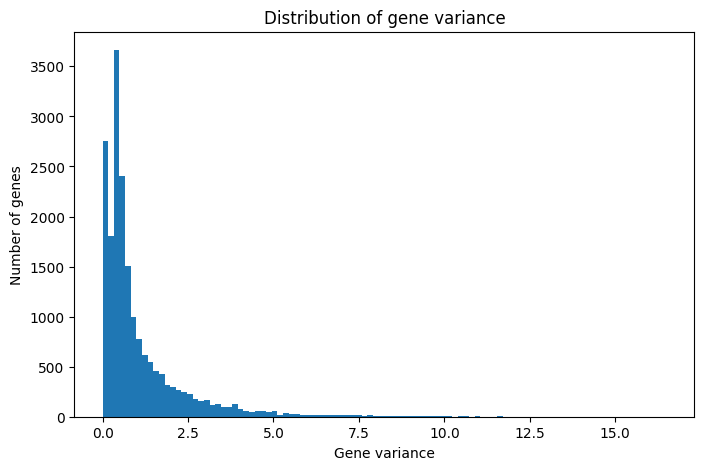

In [26]:
# =============================================================================
# Gene variance distribution
# =============================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    gene_summary["variance"],
    bins=100
)

plt.xlabel("Gene variance")
plt.ylabel("Number of genes")
plt.title("Distribution of gene variance")

plt.show()

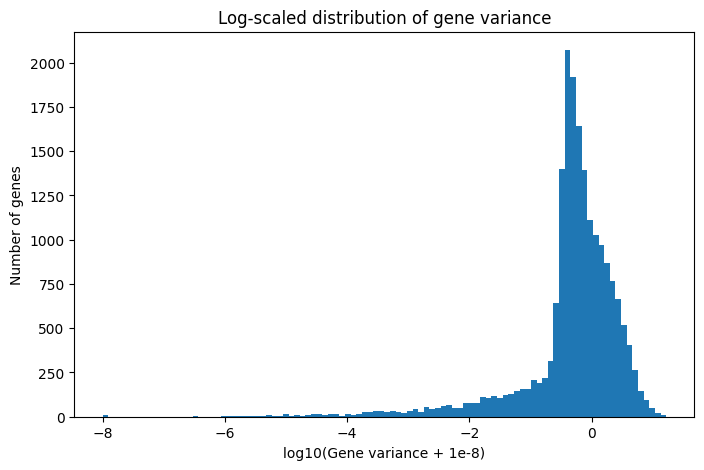

In [27]:
# =============================================================================
# Log-scaled gene variance distribution
# =============================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    np.log10(gene_summary["variance"] + 1e-8),
    bins=100
)

plt.xlabel("log10(Gene variance + 1e-8)")
plt.ylabel("Number of genes")
plt.title("Log-scaled distribution of gene variance")

plt.show()

In [28]:
# =============================================================================
# Zero and near-zero variance genes
# =============================================================================

variance_thresholds = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

variance_threshold_summary = pd.DataFrame({
    "variance_threshold": variance_thresholds,
    "genes_below_or_equal_threshold": [
        (gene_summary["variance"] <= threshold).sum()
        for threshold in variance_thresholds
    ]
})

variance_threshold_summary["genes_retained"] = (
    gene_summary.shape[0]
    - variance_threshold_summary["genes_below_or_equal_threshold"]
)

variance_threshold_summary["retained_pct"] = (
    variance_threshold_summary["genes_retained"]
    / gene_summary.shape[0]
    * 100
).round(2)

display(variance_threshold_summary)

,variance_threshold,genes_below_or_equal_threshold,genes_retained,retained_pct
0,0.000000,10,19183,99.95
1,0.000001,17,19176,99.91
2,0.000010,67,19126,99.65
3,0.000100,180,19013,99.06
4,0.001000,435,18758,97.73
5,0.010000,987,18206,94.86


In [ ]:
# =============================================================================
# Genes with lowest variance
# =============================================================================

display(
    gene_summary
    .sort_values("variance", ascending=True)
    .head()
)

,gene,mean_expression,median_expression,std_expression,variance,min_expression,max_expression
DEFB130A (245940),DEFB130A (245940),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
DEFB128 (245939),DEFB128 (245939),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
DEFB127 (140850),DEFB127 (140850),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
USP17L5 (728386),USP17L5 (728386),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
DEFB130B (100133267),DEFB130B (100133267),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
USP17L10 (100287144),USP17L10 (100287144),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
DEFB131A (644414),DEFB131A (644414),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
OR5AS1 (219447),OR5AS1 (219447),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
FAM236D (105373251),FAM236D (105373251),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000
FAM236C (109729126),FAM236C (109729126),0.00000,0.0,0.000000,0.000000e+00,0.0,0.000000


In [ ]:
# =============================================================================
# Genes with highest variance
# =============================================================================

display(
    gene_summary
    .sort_values("variance", ascending=False)
    .head()
)

,gene,mean_expression,median_expression,std_expression,variance,min_expression,max_expression
KRT19 (3880),KRT19 (3880),5.525932,5.272023,4.060954,16.491343,0.000000,13.367961
SPARC (6678),SPARC (6678),4.683981,3.353323,3.829399,14.664293,0.000000,14.310328
C19orf33 (64073),C19orf33 (64073),4.677861,4.084915,3.788655,14.353906,0.000000,11.047533
KRT7 (3855),KRT7 (3855),5.164964,3.800123,3.786881,14.340468,0.000000,12.833029
VIM (7431),VIM (7431),6.938549,7.850812,3.785886,14.332934,0.000000,13.275106
UCHL1 (7345),UCHL1 (7345),4.972169,4.571070,3.752823,14.083681,0.000000,11.485880
RPS4Y1 (6192),RPS4Y1 (6192),2.889896,0.632268,3.695655,13.657867,0.000000,11.300467
TGFBI (7045),TGFBI (7045),5.278118,5.276497,3.628366,13.165036,0.000000,12.935884
KRT8 (3856),KRT8 (3856),7.320577,8.306335,3.612489,13.050073,0.000000,13.536976
S100P (6286),S100P (6286),3.821439,1.839960,3.587635,12.871123,0.000000,14.264663


In [31]:
# =============================================================================
# Save gene variability summary
# =============================================================================

gene_summary.to_csv(
    INTERIM_DIR / "24_gene_variability_summary.csv",
    index=False
)

variance_threshold_summary.to_csv(
    INTERIM_DIR / "24_expression_qc_summary.csv",
    index=False
)

### Gene Variability Assessment

The transcriptomic feature space exhibits a broad range of variability across the integrated cohort.

Only 10 genes displayed zero variance across all 713 cell lines, indicating that nearly the entire transcriptomic matrix contains measurable variation. Low-variance genes were predominantly composed of olfactory receptors, defensin-family genes, and poorly expressed transcripts.

Variance quantile analysis demonstrated that the majority of genes retain substantial variability, with a median variance of 0.58 and a pronounced right-skewed distribution characteristic of large transcriptomic datasets.

The most variable genes included epithelial, mesenchymal, and lineage-associated markers such as KRT19, KRT7, KRT8, KRT18, VIM, EPCAM, and SPARC, suggesting that biologically meaningful heterogeneity is preserved within the cohort.

No variance-based filtering was applied at this stage. The generated variability metrics will serve as a reference for downstream preprocessing decisions.

In [32]:
qc_summary = pd.DataFrame({
    "metric": [
        "models",
        "genes",
        "missing_values",
        "zero_variance_genes",
        "potential_sample_outliers",
        "median_gene_variance",
        "variance_95th_percentile"
    ],
    "value": [
        expression.shape[0],
        expression.shape[1] - 1,
        0,
        10,
        len(potential_outliers),
        gene_summary["variance"].median(),
        gene_summary["variance"].quantile(0.95)
    ]
})

display(qc_summary)

,metric,value
0,models,713.000000
1,genes,19193.000000
2,missing_values,0.000000
3,zero_variance_genes,10.000000
4,potential_sample_outliers,13.000000
5,median_gene_variance,0.578146
6,variance_95th_percentile,3.766832
